# How good is the fixed-block gMPS conversion of CPMC walkers?

`mps_cpmc_new.py` turns every walker determinant into a Gaussian MPS (Fishman–White): at each site $k$ it diagonalises the correlation matrix on a block of $B_k$ sites, rotates the most nearly pure mode onto site $k$ with $B_k-1$ Givens gates, and moves on. The **block sizes $B_k$ are frozen once**, on a reference determinant (`make_orbital_plan(..., "adaptive")` on the trial's natural orbitals). Every walker then gets its own angles, but the same $B_k$, so the same gates, circuit and bond labels, which is what makes the conversion jittable.

That is exact for the reference and approximate for everyone else. If a walker would need a bigger block at site $k$ to hold a pure mode, the fixed block hands it a mode that is only *nearly* pure, and the conversion drops norm.

This notebook measures that on real walkers. It runs a plain HF-trial CPMC with trot (UHF trial; the propagation involves no MPS at all). After every block, it converts each walker's two spin channels twice:

1. **Own plan.** The walker picks its own block sizes, $B_k(\phi)$ = the smallest block at site $k$ holding a mode with occupation within $\varepsilon$ of 0 or 1 (the same rule as the reference plan). All of them are saved: per block, walker, spin and site.
2. **Fixed plan**, the reference's $B_k$. The norm it keeps is the fidelity $F=|\langle\mathrm{gMPS}|\phi\rangle|^2$ for normalised $\phi$ (see below).
3. **Fixed plan plus bond truncation** (optional, `CHI_W`). Production's `walker_channel_chi`: per-sector kept counts frozen on the reference by `plan_bonds`, the gMPS built by `channel_mps(Q, plan, bond_plan)`. This measures the norm the truncation drops, and the error it puts on the walker's overlap with the trial, the quantity CPMC actually uses.

| symbol | meaning |
|---|---|
| $L$, $N_\sigma$ | sites, electrons of spin $\sigma$ |
| $\phi_\sigma$ | a walker's $L\times N_\sigma$ orbital matrix, orthonormalised by QR before converting |
| $\varepsilon$ | purity tolerance of the adaptive rule (`occupation_tolerance` in `mps_cpmc_new.py`, $10^{-10}$) |
| $B_k^{\rm ref}$ | block size at site $k$ of the fixed plan, from the UHF reference determinant |
| $B_k(\phi)$ | block size the walker itself would choose at site $k$ |
| $R$ | the orbital matrix after all of the plan's rotations; row $k$ is the mode placed on site $k$ |
| $F_\sigma = \det\big(R[\mathrm{occ},:]\big)^2$ | fidelity kept by a plan for one spin; $F=F_\uparrow F_\downarrow$ per walker |
| $\chi_w$ | walker bond dimension per spin channel after truncation (`walker_channel_chi`); the d=4 walker bond is $\chi_w^2$ |
| $F^{\rm bond}_\sigma$ | fidelity of the truncated gMPS against the untruncated fixed-plan gMPS: the truncation's own loss |
| $O=\langle\Psi_T\vert\phi\rangle$ | the walker's overlap with the trial; $\delta O = \vert O_{\rm gMPS}/O-1\vert$ is its relative error |

**Why $F_\sigma=\det(R[\mathrm{occ},:])^2$.** The circuit places a product state on the sites: occupied sites (occ) and empty ones. Undoing the rotations turns it into the determinant whose orbitals are the rotated unit vectors on the occupied sites. Its overlap with $\phi$ is the determinant of $\phi$'s rotated orbitals restricted to those rows, $\det R[\mathrm{occ},:]$: the `gauge` that `channel_mps` returns. It is $\pm1$ when every chosen mode is exactly pure, and less than 1 in magnitude when a block was too small. So $1-F$ is the norm the fixed plan throws away, *before* any walker bond truncation. For the walker's own plan, $1-F$ is $O(\varepsilon)$: the floor.

In [20]:
# ---- system
L, N_UP, N_DN = 32, 16, 16
T, U = 1.0, 4.0            # open chain, as in mps_cpmc_new.py
# ---- CPMC (trot defaults otherwise: weight_cap, pop control, SR every block)
N_WALKERS = 200
N_EQL = 20                 # blocks before the energy average starts (all blocks are analysed)
N_BLOCKS = 100             # sampling blocks after N_EQL
N_PROP = 20                # steps per block
DT = 0.01
SEED = 1234
# ---- conversion
EPS = 1.0e-10              # purity tolerance for both plans (mps_cpmc_new default)
CHI_W = (2, 4, 8)          # walker bond per spin channel to test (walker_channel_chi); () = no truncation
# ---- data: each stage is cached in fw_block_data/ and recomputed only if its file is
# missing or RERUN = True. The walkers file holds every snapshot, so changing CHI_W or
# EPS never reruns the CPMC.
RERUN = True

In [21]:
import dataclasses
import json
import sys
import time
from pathlib import Path

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

sys.path.insert(0, str(Path.cwd()))           # this folder: mps_cpmc_new.py
from mps_cpmc_new import make_orbital_plan, channel_angles, channel_mps, hopping_matrix, plan_bonds
from trot.core.system import System
from trot.driver import make_run_blocks
from trot.ham.chol import HamChol
from trot.ham.hubbard import HamHubbard
from trot.meas.ghf import make_ghf_meas_ops_hubbard
from trot.meas.uhf import make_uhf_meas_ops
from trot.prop import blocks, cpmc, cpmc_slow
from trot.prop.types import QmcParams
from trot.stat_utils import blocking_analysis_ratio
from trot.trial.ghf import GhfTrial, make_ghf_trial_ops
from trot.trial.uhf import UhfTrial, make_uhf_trial_ops

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#8e5bd0", "#d4a20f", "#d6457a"]
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 1.0, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 14, "axes.labelsize": 10, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2.0,
    "lines.solid_capstyle": "round", "legend.frameon": False, "font.size": 10,
})
LEGEND = dict(loc="upper left", bbox_to_anchor=(1.01, 1.0))

DATA_DIR = Path("fw_block_data")
DATA_DIR.mkdir(exist_ok=True)
RUN_TAG = f"L{L}_U{U:g}_nw{N_WALKERS}_s{SEED}"
TAG = f"L{L}_U{U:g}_nw{N_WALKERS}_eps{EPS:.0e}_s{SEED}"
WALKERS = DATA_DIR / f"{RUN_TAG}_walkers.npz"      # the CPMC run: every snapshot's walkers
DATA = DATA_DIR / f"{TAG}.npz"                     # block sizes and plan fidelities
trunc_file = lambda chi: DATA_DIR / f"{TAG}_chi{chi}.npz"   # truncation, one file per chi_w (0 = none)


def save(fig, name):
    path = DATA_DIR / f"{TAG}_{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")

## UHF trial

Self-consistent UHF for the open Hubbard chain: $F_\sigma = h + U\,\mathrm{diag}(n_{\bar\sigma})$, occupy the lowest $N_\sigma$ levels, mix the densities, repeat. It starts from a Néel guess, so at half filling it lands on the antiferromagnetic solution.

In [22]:
h1 = hopping_matrix(L, T)


def uhf_scf(h1, u, na, nb, guess=0.3, mix=0.5, tol=1e-12, iters=5000):
    n = h1.shape[0]
    stag = (-1.0) ** np.arange(n)
    da, db = na / n + guess * stag, nb / n - guess * stag
    for it in range(iters):
        _, va = np.linalg.eigh(h1 + u * np.diag(db))
        _, vb = np.linalg.eigh(h1 + u * np.diag(da))
        Ca, Cb = va[:, :na], vb[:, :nb]
        new_a, new_b = np.einsum("ik,ik->i", Ca, Ca), np.einsum("ik,ik->i", Cb, Cb)
        change = max(abs(new_a - da).max(), abs(new_b - db).max())
        da, db = (1 - mix) * da + mix * new_a, (1 - mix) * db + mix * new_b
        if change < tol:
            break
    Pa, Pb = Ca @ Ca.T, Cb @ Cb.T
    energy = np.sum(h1 * (Pa + Pb)) + u * np.diag(Pa) @ np.diag(Pb)
    return Ca, Cb, energy, it, change


Ca, Cb, E_UHF, it, change = uhf_scf(h1, U, N_UP, N_DN)
m = np.einsum("ik,ik->i", Ca, Ca) - np.einsum("ik,ik->i", Cb, Cb)
print(f"UHF: E = {E_UHF:.10f}  ({it} iterations, last density change {change:.1e})")
print(f"staggered moment (n_up - n_dn), first sites: {np.round(m[:6], 3)}")

UHF: E = -14.5691763857  (64 iterations, last density change 8.6e-13)
staggered moment (n_up - n_dn), first sites: [ 0.876 -0.762  0.771 -0.769  0.769 -0.769]


## The UHF trial in trot

Everything here is trot's own code:

| piece | trot function |
|---|---|
| trial | `trial/uhf.py`: `UhfTrial`, `make_uhf_trial_ops` (overlap, one-body density matrix) |
| energy | `meas/uhf.py`: `make_uhf_meas_ops` |
| propagation | `prop/cpmc_slow.py` with `prop/hubbard_cpmc_ops.py`: discrete spin HS fields, $e^{-\Delta\tau K/2}$ half steps, constraint, population control |
| blocks, SR | `prop/blocks.py`, `driver.make_run_blocks` |

Two points need a comment.

**Slow step.** `cpmc_slow` recomputes both proposed overlaps per site as determinants; it needs only the trial's `overlap`. The fast step (`prop/cpmc.py`) gets the same ratios from rank-2 Green's-function updates, but trot's UHF trial ops don't provide those. The two are the same algorithm: same random numbers, same probabilities, same weights up to roundoff. So they sample the same walker ensemble, and nothing measured below depends on which one runs.

**Energy.** `meas/uhf.py` evaluates a Cholesky Hamiltonian, $\hat V=\tfrac12\sum_g\sum_{ij,kl}L^g_{ij}L^g_{kl}\,c^\dagger_{i\sigma}c^\dagger_{k\tau}c_{l\tau}c_{j\sigma}$. The Hubbard interaction is exactly of that form with one vector per site, $L^g=\sqrt U\,|g\rangle\langle g|$. Its Hartree term gives $\tfrac U2\sum_g(G^\uparrow_{gg}+G^\downarrow_{gg})^2$, and the same-spin exchange removes $\tfrac U2\sum_g\big[(G^\uparrow_{gg})^2+(G^\downarrow_{gg})^2\big]$, which leaves $U\sum_g G^\uparrow_{gg}G^\downarrow_{gg}$. So the measurement gets a `HamChol` with $h_1$ = hopping and those $L$ vectors, while the propagator keeps the `HamHubbard`. `cpmc_slow.make_prop_ops` stores its own `HamHubbard`, and the `ham_data` passed through the blocks reaches only the energy kernel.

**Check.** Two blocks of trot's *fast* step with its `GhfTrial` / Hubbard GHF measurement, on the block-diagonal orbitals $\mathrm{diag}(\Psi_\uparrow,\Psi_\downarrow)$ (the same state), must give the same energies and walkers, up to roundoff.

In [23]:
ham = HamHubbard(h1=jnp.asarray(h1), u=U)                     # propagation
onsite = np.zeros((L, L, L))
onsite[np.arange(L), np.arange(L), np.arange(L)] = np.sqrt(U)
ham_meas = HamChol(h0=jnp.zeros(()), h1=jnp.asarray(h1), chol=jnp.asarray(onsite))   # U n_up n_dn as L Cholesky vectors

system = System(norb=L, nelec=(N_UP, N_DN), walker_kind="unrestricted")
trial = UhfTrial(mo_coeff_a=jnp.asarray(Ca), mo_coeff_b=jnp.asarray(Cb))
TRIAL_OPS = make_uhf_trial_ops(system)
MEAS_OPS = make_uhf_meas_ops(system)
PROP_OPS = cpmc_slow.make_prop_ops(ham, "unrestricted")
params = QmcParams(dt=DT, n_walkers=N_WALKERS, n_prop_steps=N_PROP, n_blocks=N_BLOCKS,
                   n_eql_blocks=N_EQL, seed=SEED)


def setup(prop_ops, trial_ops, meas_ops, trial_data, ham_data, params):
    run_blocks = make_run_blocks(block_fn=blocks.block, sys=system, params=params,
                                 trial_ops=trial_ops, meas_ops=meas_ops, prop_ops=prop_ops)
    ctx = dict(ham_data=ham_data, trial_data=trial_data,
               meas_ctx=meas_ops.build_meas_ctx(ham_data, trial_data),
               prop_ctx=prop_ops.build_prop_ctx(ham, trial_ops.get_rdm1(trial_data), params))
    state = prop_ops.init_prop_state(sys=system, ham_data=ham_data, trial_ops=trial_ops,
                                     trial_data=trial_data, meas_ops=meas_ops, params=params)
    return run_blocks, ctx, state


small = dataclasses.replace(params, n_walkers=16)
ghf_trial = GhfTrial(mo_coeff=jnp.asarray(scipy.linalg.block_diag(Ca, Cb)))
ghf_ops = make_ghf_trial_ops(system)
out = {}
for name, args in [("UHF, slow step", (PROP_OPS, TRIAL_OPS, MEAS_OPS, trial, ham_meas)),
                   ("GHF, fast step", (cpmc.make_prop_ops(ham, "unrestricted", ghf_ops), ghf_ops,
                                       make_ghf_meas_ops_hubbard(system), ghf_trial, ham))]:
    run_blocks, ctx, state = setup(*args, small)
    out[name] = run_blocks(state, **ctx, n_blocks=2)[:2]
    print(f"block energies, {name}: {np.asarray(out[name][1]['energy'])}")
(s1, _), (s2, _) = out.values()
print("max |walker difference|:", max(float(jnp.abs(a - b).max()) for a, b in zip(s1.walkers, s2.walkers)))

block energies, UHF, slow step: [-15.58212476 -15.84760383]
block energies, GHF, fast step: [-15.58212476 -15.84760383]
max |walker difference|: 0.0


## The fixed plan

Planned on the UHF determinant, spin by spin: exactly what `mps_cpmc_new.py` does with `plan_reference="natural"` for a UHF trial, since a single determinant's natural orbitals are its own orbitals. trot starts every walker from the trial's natural orbitals, so at $\tau=0$ every walker *is* the reference and both plans coincide.

In [24]:
PLAN = [make_orbital_plan(C, "adaptive", EPS) for C in (Ca, Cb)]
B_REF = np.stack([p.block_sizes for p in PLAN])           # (2, L-1)
for s, p in zip("↑↓", PLAN):
    print(f"spin {s}: B_k = {p.block_sizes.tolist()}")
    print(f"        gates = {int((p.block_sizes - 1).sum())},  max B = {p.block_sizes.max()}  ->  "
          f"bond up to 2^(B-1) = {2 ** (p.block_sizes.max() - 1)} before truncation")

spin ↑: B_k = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 3, 3, 2, 2]
        gates = 112,  max B = 5  ->  bond up to 2^(B-1) = 16 before truncation
spin ↓: B_k = [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 3, 3, 2, 2]
        gates = 112,  max B = 5  ->  bond up to 2^(B-1) = 16 before truncation


## Converting every walker, every block

`analyse` runs on the walkers at the end of each block: after trot's stochastic reconfiguration, so every walker has the same weight and plain averages over walkers are weighted averages. For each walker and spin it:

- QR-orthonormalises $\phi_\sigma$;
- builds the walker's own plan, `make_orbital_plan(Q, "adaptive", EPS)`, and keeps its $B_k(\phi)$;
- computes $F_\sigma$ for the fixed plan and for the own plan, via `channel_angles` (the angle computation `channel_mps` uses) and $\det R[\mathrm{occ},:]^2$.

Only the circuit geometry is needed for this, not the MPS tensors. The explicit gMPS is built for a few walkers further down, as a check.

In [25]:
def fidelity(Q, plan):
    _, rows = channel_angles(Q, plan, xp=np)
    return np.linalg.det(np.stack([rows[i] for i in np.flatnonzero(plan.occupation)])) ** 2


def analyse(walkers):
    nw = walkers[0].shape[0]
    B = np.zeros((nw, 2, L - 1), np.int8)
    F_fixed, F_own = np.zeros((nw, 2)), np.zeros((nw, 2))
    for s in range(2):
        W = np.asarray(walkers[s])
        for w in range(nw):
            Q, _ = np.linalg.qr(W[w])
            own = make_orbital_plan(Q, "adaptive", EPS)
            B[w, s] = own.block_sizes
            F_own[w, s] = fidelity(Q, own)
            F_fixed[w, s] = fidelity(Q, PLAN[s])
    return B, F_fixed, F_own

## The run

One jitted trot block at a time, so the walkers can be read between blocks. Snapshot 0 is the initial population at $\tau=0$; snapshot $b$ is taken after block $b$, at $\tau=b\,N_{\rm prop}\,\Delta\tau$.

The run saves every snapshot's walkers (float64, about 160 MB at L=32 with 200 walkers; compression doesn't help). Every analysis below reads that file, so a new `EPS` or `CHI_W` never repeats the CPMC.

In [26]:
if RERUN or not WALKERS.exists():
    run_blocks, ctx, state = setup(PROP_OPS, TRIAL_OPS, MEAS_OPS, trial, ham_meas, params)
    n_total = N_EQL + N_BLOCKS
    snaps_up, snaps_dn, energies, weights = [], [], [], []
    start = time.perf_counter()
    for b in range(n_total + 1):
        if b:
            state, scalars, _ = run_blocks(state, **ctx, n_blocks=1)
            energies.append(float(scalars["energy"][0]))
            weights.append(float(scalars["weight"][0]))
        snaps_up.append(np.asarray(state.walkers[0]))
        snaps_dn.append(np.asarray(state.walkers[1]))
        if b % 20 == 0:
            print(f"block {b:4d}/{n_total}  E {energies[-1] if b else float(state.e_estimate):12.6f}"
                  f"  t {time.perf_counter() - start:6.1f} s", flush=True)
    config = dict(L=L, N_UP=N_UP, N_DN=N_DN, T=T, U=U, N_WALKERS=N_WALKERS, N_EQL=N_EQL,
                  N_BLOCKS=N_BLOCKS, N_PROP=N_PROP, DT=DT, SEED=SEED, E_UHF=E_UHF)
    np.savez_compressed(WALKERS, up=np.stack(snaps_up), dn=np.stack(snaps_dn), energies=np.array(energies),
                        weights=np.array(weights), config=json.dumps(config))
    print(f"saved {WALKERS}")

run = np.load(WALKERS)
WALK = (run["up"], run["dn"])                # each (n_snap, n_walkers, L, N_sigma)
energies, weights = run["energies"], run["weights"]
tau = np.arange(WALK[0].shape[0]) * N_PROP * DT   # snapshot b at tau = b * N_PROP * DT
samp = slice(N_EQL + 1, None)                     # snapshots after the equilibration blocks
print(f"{len(tau)} snapshots x {WALK[0].shape[1]} walkers, tau up to {tau[-1]:g}")

block    0/120  E   -14.569176  t    0.0 s
block   20/120  E   -17.678027  t   17.5 s
block   40/120  E   -17.783750  t   33.2 s
block   60/120  E   -17.535869  t   48.8 s
block   80/120  E   -17.923941  t   64.5 s
block  100/120  E   -17.383404  t   79.9 s
block  120/120  E   -17.872002  t   95.6 s
saved fw_block_data/L32_U4_nw200_s1234_walkers.npz
121 snapshots x 200 walkers, tau up to 24


In [27]:
if RERUN or not DATA.exists():
    start, out = time.perf_counter(), [analyse((up, dn)) for up, dn in zip(*WALK)]
    np.savez_compressed(DATA, block_sizes=np.stack([o[0] for o in out]), fid_fixed=np.stack([o[1] for o in out]),
                        fid_own=np.stack([o[2] for o in out]), plan_block_sizes=B_REF)
    print(f"analysed {len(out)} snapshots in {time.perf_counter() - start:.0f} s; saved {DATA}")

data = np.load(DATA)
BS = data["block_sizes"].astype(int)        # (n_snap, n_walkers, 2, L-1)
FF = data["fid_fixed"]                       # (n_snap, n_walkers, 2)
FO = data["fid_own"]
print(f"{BS.shape[0]} snapshots x {BS.shape[1]} walkers x 2 spins x {BS.shape[3]} sites")

analysed 121 snapshots in 155 s; saved fw_block_data/L32_U4_nw200_eps1e-10_s1234.npz
121 snapshots x 200 walkers x 2 spins x 31 sites


### Checks: explicit gMPS, and the energy

For a few final walkers, build the actual gMPS with `channel_mps` (no bond truncation) using both plans, and compare the overlap with the trial's gMPS, $g_T\,g_W\,\langle\mathrm{gMPS}_T|\mathrm{gMPS}_W\rangle$, against $\det(\Psi^{\mathsf T}Q)$. Neither plan is exact. A mode pure to $\varepsilon$ in occupation can still be off by $\sim\sqrt\varepsilon$ in amplitude, so even the own plan agrees only to a relative error of order $\sqrt{1-F}/|\langle\Psi|\phi\rangle|$, about $10^{-7}$ here, not $\varepsilon$. Where the fixed plan's block is *larger* than the walker's own, the fixed plan is the more accurate of the two.

**Spin symmetry.** At half filling on a bipartite chain, the Néel UHF trial and trot's spin-decomposition HS fields are particle-hole symmetric. Every walker keeps $P_\downarrow = 1 - S P_\uparrow S$ with $S=\mathrm{diag}((-1)^i)$, and the pure modes of $1-P$ are those of $P$ with $n\to1-n$. So $F_\downarrow=F_\uparrow$ exactly, and the ↓ channel adds no independent information. Its block sizes differ from ↑ only through ties at the $\varepsilon$ threshold. The cell below checks this.

In [28]:
def mps_dot(A, B):
    E = np.ones((1, 1))
    for a, b in zip(A, B):
        E = np.einsum("ab,apc,bpd->cd", E, np.asarray(a), np.asarray(b))
    return E[0, 0]


final = (WALK[0][-1], WALK[1][-1])
trial_mps = [channel_mps(jnp.asarray(C), p) for C, p in zip((Ca, Cb), PLAN)]
worst = np.argsort(FF[-1].prod(1))[:2]                  # the two walkers the fixed plan fits worst
print(" walker spin   det(Psi^T Q)      own-plan rel.err   fixed-plan rel.err   1-F_fixed   bond (own/fixed)")
for w in [0, *worst]:
    for s in range(2):
        Q, _ = np.linalg.qr(final[s][w])
        exact = np.linalg.det(np.asarray((Ca, Cb)[s]).T @ Q)
        tT, _, gT = trial_mps[s]
        row = []
        for plan in (make_orbital_plan(Q, "adaptive", EPS), PLAN[s]):
            tW, _, gW = channel_mps(jnp.asarray(Q), plan)
            row.append((float(gT * gW) * mps_dot(tT, tW), max(a.shape[0] for a in tW)))
        print(f"  {w:4d}   {'↑↓'[s]}   {exact:+.6e}      {abs(row[0][0] / exact - 1):.1e}"
              f"            {abs(row[1][0] / exact - 1):.1e}           {1 - FF[-1, w, s]:.1e}     "
              f"{row[0][1]}/{row[1][1]}")

a, b = final[0][0], final[1][0]
P_up, P_dn = (x @ np.linalg.solve(x.T @ x, x.T) for x in (a, b))
stag = np.diag((-1.0) ** np.arange(L))
print(f"\nparticle-hole symmetry: max |P_dn - (1 - S P_up S)| = {np.abs(P_dn - (np.eye(L) - stag @ P_up @ stag)).max():.1e}, "
      f"max |F_up - F_dn| over the run = {np.abs(FF[..., 0] - FF[..., 1]).max():.1e}, "
      f"B_up != B_dn in {(BS[:, :, 0] != BS[:, :, 1]).sum()} of {BS[:, :, 0].size} (snapshot, walker, site) entries")

stats = blocking_analysis_ratio(energies[N_EQL:], weights[N_EQL:], print_q=False)
print(f"\nCPMC energy (UHF trial): {stats['mu']:.6f} +- {stats['se_star']:.6f}   UHF: {E_UHF:.6f}")

 walker spin   det(Psi^T Q)      own-plan rel.err   fixed-plan rel.err   1-F_fixed   bond (own/fixed)
     0   ↑   +1.186479e-01      1.7e-07            7.8e-09           2.1e-10     32/16
     0   ↓   -1.186479e-01      1.7e-07            7.8e-09           2.1e-10     32/16
   177   ↑   -5.799224e-01      2.6e-10            6.8e-07           1.5e-07     32/16
   177   ↓   +5.799224e-01      2.6e-10            6.8e-07           1.5e-07     32/16
    64   ↑   -8.470969e-02      2.2e-07            2.8e-08           1.3e-07     32/16
    64   ↓   -8.470969e-02      2.2e-07            2.8e-08           1.3e-07     32/16

particle-hole symmetry: max |P_dn - (1 - S P_up S)| = 4.8e-15, max |F_up - F_dn| over the run = 8.1e-14, B_up != B_dn in 1 of 750200 (snapshot, walker, site) entries

CPMC energy (UHF trial): -17.618055 +- 0.049117   UHF: -14.569176


## Block sizes along the run

The walker's largest block, $\max_k B_k(\phi)$, sets its gate depth and the $2^{B-1}$ bond bound. The band is the 5–95% range over walkers and spins.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_max_block.png


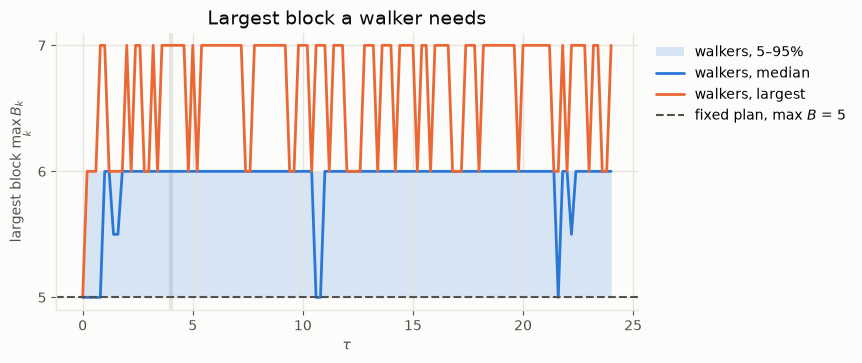

In [29]:
bmax = BS.max(axis=3).reshape(len(tau), -1)             # per walker-channel
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.fill_between(tau, np.percentile(bmax, 5, axis=1), np.percentile(bmax, 95, axis=1),
                color=PALETTE[0], alpha=0.18, lw=0, label="walkers, 5–95%")
ax.plot(tau, np.median(bmax, axis=1), color=PALETTE[0], label="walkers, median")
ax.plot(tau, bmax.max(axis=1), color=PALETTE[1], label="walkers, largest")
ax.axhline(B_REF.max(), color=INK2, ls="--", lw=1.5, label=f"fixed plan, max $B$ = {B_REF.max()}")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"largest block $\max_k B_k$")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_title("Largest block a walker needs")
ax.legend(**LEGEND)
save(fig, "max_block"); plt.show()

The fixed plan is only wrong where a walker needs a *bigger* block than the plan gives it at the same site. A smaller one costs nothing, since the larger block still contains the pure mode. The plot shows, against $\tau$, the fraction of walker channels with at least one such site, and the fraction of all (walker, spin, site) entries that are too big.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_excess_fraction.png


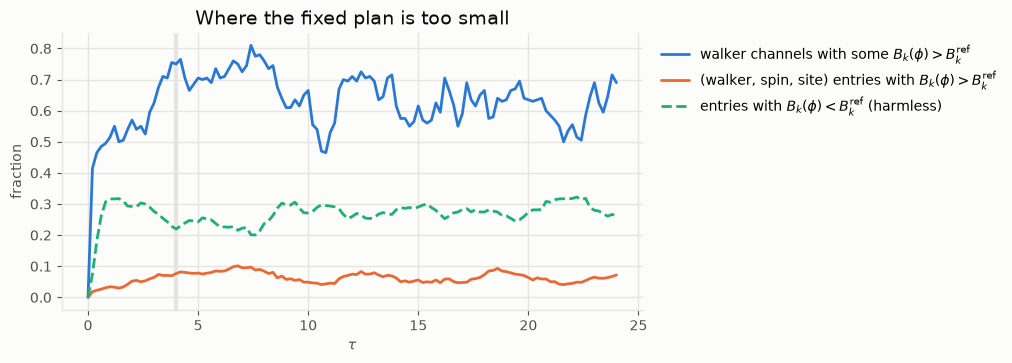

In [30]:
excess = BS - B_REF[None, None]                          # (n_snap, nw, 2, L-1)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau, (excess > 0).any(axis=3).mean(axis=(1, 2)), color=PALETTE[0],
        label=r"walker channels with some $B_k(\phi) > B_k^{\rm ref}$")
ax.plot(tau, (excess > 0).mean(axis=(1, 2, 3)), color=PALETTE[1],
        label=r"(walker, spin, site) entries with $B_k(\phi) > B_k^{\rm ref}$")
ax.plot(tau, (excess < 0).mean(axis=(1, 2, 3)), color=PALETTE[2], ls="--",
        label=r"entries with $B_k(\phi) < B_k^{\rm ref}$ (harmless)")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("fraction")
ax.set_title("Where the fixed plan is too small")
ax.legend(**LEGEND)
save(fig, "excess_fraction"); plt.show()

### Per site

The profile over the chain, averaged over walkers, spins and sampling snapshots, against the fixed plan. The plan shrinks toward the right end, because fewer sites remain to form a block.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_site_profile.png


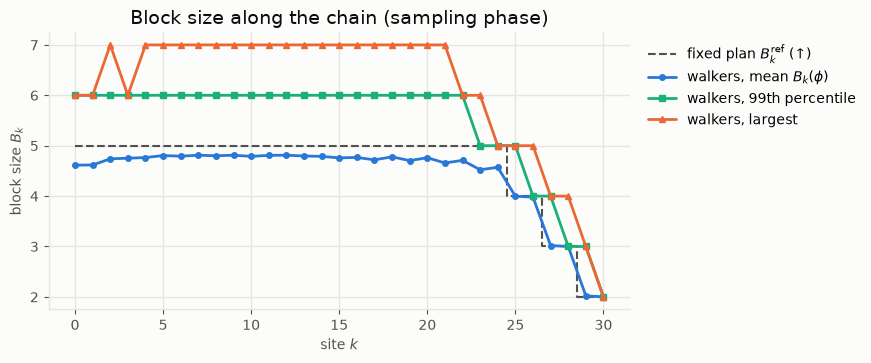

In [31]:
sites = np.arange(L - 1)
Bs = BS[samp].reshape(-1, L - 1)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.step(sites, B_REF[0], where="mid", color=INK2, ls="--", lw=1.5, label=r"fixed plan $B_k^{\rm ref}$ (↑)")
if not np.array_equal(B_REF[0], B_REF[1]):
    ax.step(sites, B_REF[1], where="mid", color=INK2, ls=":", lw=1.5, label=r"fixed plan $B_k^{\rm ref}$ (↓)")
ax.plot(sites, Bs.mean(0), "o-", color=PALETTE[0], ms=4, label=r"walkers, mean $B_k(\phi)$")
ax.plot(sites, np.percentile(Bs, 99, axis=0), "s-", color=PALETTE[2], ms=4, label=r"walkers, 99th percentile")
ax.plot(sites, Bs.max(0), "^-", color=PALETTE[1], ms=4, label=r"walkers, largest")
ax.set_xlabel("site $k$"); ax.set_ylabel("block size $B_k$")
ax.set_title("Block size along the chain (sampling phase)")
ax.legend(**LEGEND)
save(fig, "site_profile"); plt.show()

The same excess resolved in both site and $\tau$: the fraction of walker channels whose block at site $k$ is larger than the plan's.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_excess_map.png


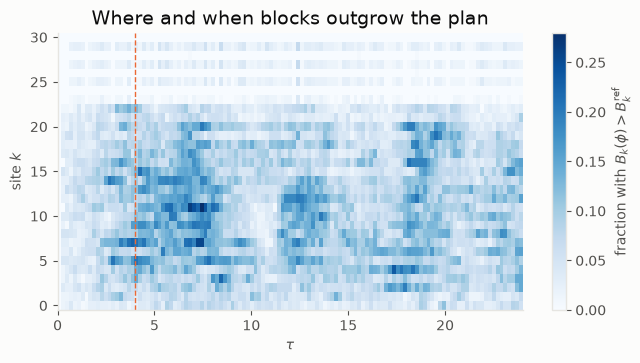

In [32]:
frac = (excess > 0).mean(axis=(1, 2))                    # (n_snap, L-1)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
im = ax.imshow(frac.T, origin="lower", aspect="auto", cmap="Blues",
               extent=(tau[0], tau[-1], -0.5, L - 1.5), interpolation="nearest")
ax.grid(False)
ax.axvline(tau[N_EQL], color=PALETTE[1], lw=1, ls="--")
fig.colorbar(im, ax=ax, label=r"fraction with $B_k(\phi) > B_k^{\rm ref}$")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("site $k$")
ax.set_title("Where and when blocks outgrow the plan")
save(fig, "excess_map"); plt.show()

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_excess_hist.png


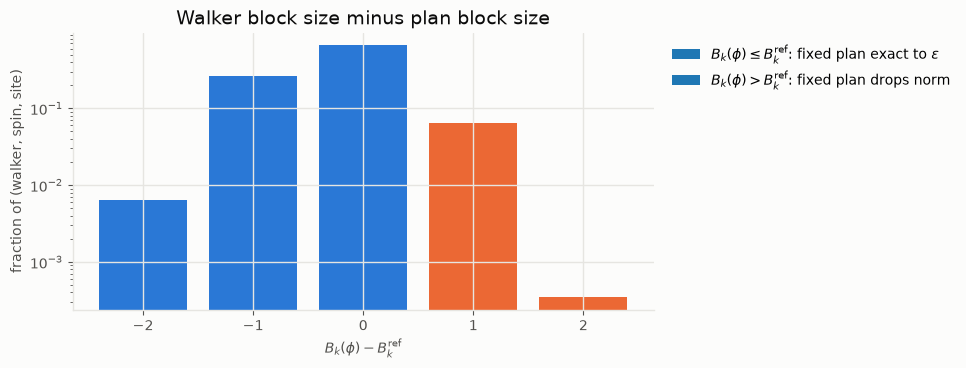

  B - B_ref   fraction
     -2      6.34e-03
     -1      2.64e-01
     +0      6.64e-01
     +1      6.54e-02
     +2      3.47e-04


In [33]:
d = excess[samp].ravel()
vals, counts = np.unique(d, return_counts=True)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar(vals, counts / counts.sum(), color=[PALETTE[1] if v > 0 else PALETTE[0] for v in vals], width=0.8)
ax.bar([], [], color=PALETTE[0], label=r"$B_k(\phi)\leq B_k^{\rm ref}$: fixed plan exact to $\varepsilon$")
ax.bar([], [], color=PALETTE[1], label=r"$B_k(\phi)> B_k^{\rm ref}$: fixed plan drops norm")
ax.set_yscale("log"); ax.set_xticks(vals)
ax.set_xlabel(r"$B_k(\phi) - B_k^{\rm ref}$"); ax.set_ylabel("fraction of (walker, spin, site)")
ax.set_title("Walker block size minus plan block size")
ax.legend(**LEGEND)
save(fig, "excess_hist"); plt.show()
print("  B - B_ref   fraction")
for v, c in zip(vals, counts):
    print(f"  {v:+5d}      {c / counts.sum():.2e}")

## What the fixed plan costs: the fidelity

$1-F$ with $F=F_\uparrow F_\downarrow$ per walker: the fraction of the walker's norm the fixed-block gMPS misses, before any bond truncation. The dotted line is the same quantity for the walkers' own plans, the floor set by $\varepsilon$.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_infidelity.png


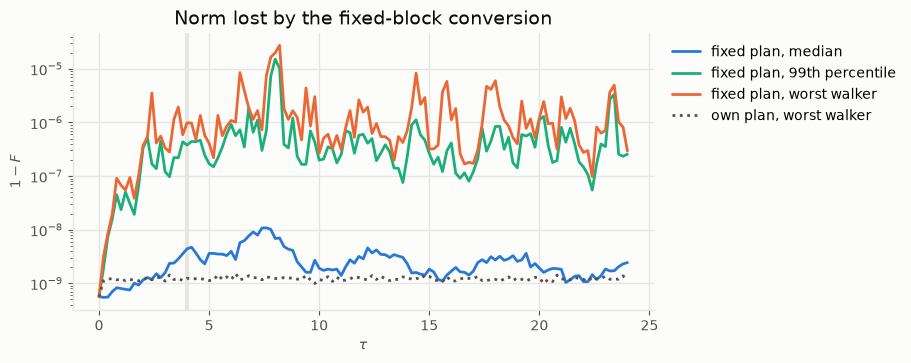

sampling phase, 20000 walker snapshots: 1-F median 2.4e-09, 99% 5.3e-07, 99.9% 4.4e-06, max 2.7e-05
own plan, max 1-F: 1.5e-09


In [34]:
inf_fixed = np.clip(1 - FF.prod(axis=2), 1e-17, None)    # (n_snap, nw)
inf_own = np.clip(1 - FO.prod(axis=2), 1e-17, None)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau, np.median(inf_fixed, axis=1), color=PALETTE[0], label="fixed plan, median")
ax.plot(tau, np.percentile(inf_fixed, 99, axis=1), color=PALETTE[2], label="fixed plan, 99th percentile")
ax.plot(tau, inf_fixed.max(axis=1), color=PALETTE[1], label="fixed plan, worst walker")
ax.plot(tau, inf_own.max(axis=1), color=INK2, ls=":", label="own plan, worst walker")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$1-F$")
ax.set_title("Norm lost by the fixed-block conversion")
ax.legend(**LEGEND)
save(fig, "infidelity"); plt.show()

x = inf_fixed[samp].ravel()
print(f"sampling phase, {x.size} walker snapshots: 1-F median {np.median(x):.1e}, "
      f"99% {np.percentile(x, 99):.1e}, 99.9% {np.percentile(x, 99.9):.1e}, max {x.max():.1e}")
print(f"own plan, max 1-F: {inf_own[samp].max():.1e}")

Is the lost norm really caused by blocks that are too small? Each walker channel, sampling phase: $1-F_\sigma$ against the summed excess $\sum_k \max(B_k(\phi)-B_k^{\rm ref},0)$.

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_infidelity_vs_excess.png


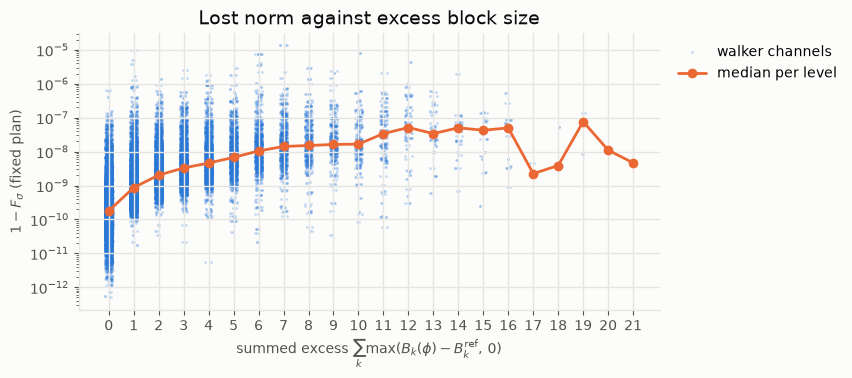

In [35]:
tot = np.clip(excess[samp], 0, None).sum(axis=3).ravel()
inf_ch = np.clip(1 - FF[samp].ravel(), 1e-17, None)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
jitter = np.random.default_rng(0).uniform(-0.15, 0.15, tot.size)
ax.scatter(tot + jitter, inf_ch, s=4, alpha=0.25, color=PALETTE[0], lw=0, label="walker channels")
levels = np.unique(tot)
ax.plot(levels, [np.median(inf_ch[tot == v]) for v in levels], "o-", color=PALETTE[1], label="median per level")
ax.set_yscale("log"); ax.set_xticks(levels)
ax.set_xlabel(r"summed excess $\sum_k\max(B_k(\phi)-B_k^{\rm ref},\,0)$")
ax.set_ylabel(r"$1-F_\sigma$ (fixed plan)")
ax.set_title("Lost norm against excess block size")
ax.legend(**LEGEND)
save(fig, "infidelity_vs_excess"); plt.show()

## Truncating the gMPS

Production also truncates the walker bond: `walker_channel_chi` $=\chi_w$ per spin channel. `plan_bonds` does a dry run on the reference and freezes, gate by gate, how many singular vectors each charge sector keeps (the $\chi_w$ largest Schmidt values overall). `channel_mps(Q, plan, bond_plan)` then splits every walker with those fixed ranks. The orthogonality centre sits on the gate, so each split drops the walker's own smallest Schmidt values in each sector, but the *allocation* across sectors is the reference's.

For every snapshot and walker, and each $\chi_w$ in `CHI_W`:

- $F^{\rm bond}_\sigma=|\langle M_\sigma|M^{\chi_w}_\sigma\rangle|^2/\langle M^{\chi_w}_\sigma|M^{\chi_w}_\sigma\rangle$, where $M_\sigma$ is the untruncated fixed-plan gMPS (norm 1). This is the loss due to truncation alone; the total fidelity against the determinant is $\approx F_\sigma F^{\rm bond}_\sigma$.
- $\delta O=|O^{\chi_w}_\uparrow O^{\chi_w}_\downarrow/(O_\uparrow O_\downarrow)-1|$, with $O^{\chi_w}_\sigma=g_T\,g\,\langle\mathrm{gMPS}_T|M^{\chi_w}_\sigma\rangle$ and the exact $O_\sigma=\det(\Psi_\sigma^{\mathsf T}Q_\sigma)$. This is the error that reaches the CPMC ratios. The row "none" is the untruncated fixed plan, so it shows the block error in the same units.

Everything is jitted and vmapped over walkers with the static plan, as in `make_walker_ops`. This costs about 0.1 s per snapshot and spin, plus about 10 s of compilation per $\chi_w$. A $\chi_w$ at or above the plan's bond, $2^{\max B-1}$, is exact.

In [36]:
def jdot(A, B):
    E = jnp.ones((1, 1))
    for a, b in zip(A, B):
        E = jnp.einsum("ab,apc,bpd->cd", E, a, b)
    return E[0, 0]


PSI = (jnp.asarray(Ca), jnp.asarray(Cb))
TRIAL_GMPS = [channel_mps(C, p)[::2] for C, p in zip(PSI, PLAN)]      # (tensors, gauge) per spin
BONDS = {0: (None, None)}
for chi in CHI_W:
    BONDS[chi] = tuple(plan_bonds(C, p, chi, 0.0) for C, p in zip((Ca, Cb), PLAN))
    print(f"chi_w = {chi}: bond labels {max(len(q) for q in BONDS[chi][0].charges)}, reference discarded weight "
          f"{BONDS[chi][0].reference_discarded_weight:.1e} (↑)  {BONDS[chi][1].reference_discarded_weight:.1e} (↓)")


def make_truncated(s, bond):
    (tT, gT), plan, psi = TRIAL_GMPS[s], PLAN[s], PSI[s]

    def one(w):
        Q, _ = jnp.linalg.qr(w)
        full, _, g = channel_mps(Q, plan)
        cut = full if bond is None else channel_mps(Q, plan, bond)[0]
        kept = jdot(cut, cut)
        return jdot(full, cut) ** 2 / kept, kept, gT * g * jdot(tT, cut) / jnp.linalg.det(psi.T @ Q)
    return jax.jit(jax.vmap(one))


TR = {}
for chi, bond in BONDS.items():
    path = trunc_file(chi)
    if RERUN or not path.exists():
        start, res = time.perf_counter(), []
        for s in range(2):
            f = make_truncated(s, bond[s])
            res.append([np.asarray(jnp.stack(f(jnp.asarray(w)))) for w in WALK[s]])   # per snapshot (3, nw)
        res = np.asarray(res)                                        # (2, n_snap, 3, nw)
        np.savez_compressed(path, f_bond=res[:, :, 0].transpose(1, 2, 0), kept=res[:, :, 1].transpose(1, 2, 0),
                            ratio=res[:, :, 2].transpose(1, 2, 0))
        print(f"chi_w = {chi or 'none'}: {time.perf_counter() - start:.0f} s, saved {path}")
    TR[chi] = dict(np.load(path))                                    # arrays (n_snap, nw, 2)
    TR[chi]["dO"] = np.abs(TR[chi]["ratio"].prod(axis=2) - 1)        # (n_snap, nw)

print("\nsampling phase           1-F_bond (per spin)             delta O (per walker)          min kept norm")
print("  chi_w           median     99%       max        median     99%       max")
for chi, t in TR.items():
    fb, dO = 1 - t["f_bond"][samp].ravel(), t["dO"][samp].ravel()
    print(f"  {str(chi or 'none'):>5}        {np.median(fb):9.1e} {np.percentile(fb, 99):9.1e} {fb.max():9.1e}"
          f"   {np.median(dO):9.1e} {np.percentile(dO, 99):9.1e} {dO.max():9.1e}     {t['kept'][samp].min():.4f}")

chi_w = 2: bond labels 2, reference discarded weight 1.0e-02 (↑)  1.0e-02 (↓)
chi_w = 4: bond labels 4, reference discarded weight 3.1e-05 (↑)  3.1e-05 (↓)
chi_w = 8: bond labels 8, reference discarded weight 5.0e-09 (↑)  5.0e-09 (↓)
chi_w = none: 28 s, saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_chi0.npz
chi_w = 2: 35 s, saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_chi2.npz
chi_w = 4: 43 s, saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_chi4.npz
chi_w = 8: 47 s, saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_chi8.npz

sampling phase           1-F_bond (per spin)             delta O (per walker)          min kept norm
  chi_w           median     99%       max        median     99%       max
   none         -1.3e-15   7.0e-15   1.3e-14     7.7e-08   5.7e-06   2.9e-04     1.0000
      2          4.4e-02   6.9e-01   1.0e+00     3.2e-02   3.8e-01   9.7e-01     0.0068
      4          2.2e-04   1.5e-02   2.4e-01     4.0e-04   3.5e-02   2.6e-01     0.7601
      8          3.3e-09  

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_truncation_fidelity.png


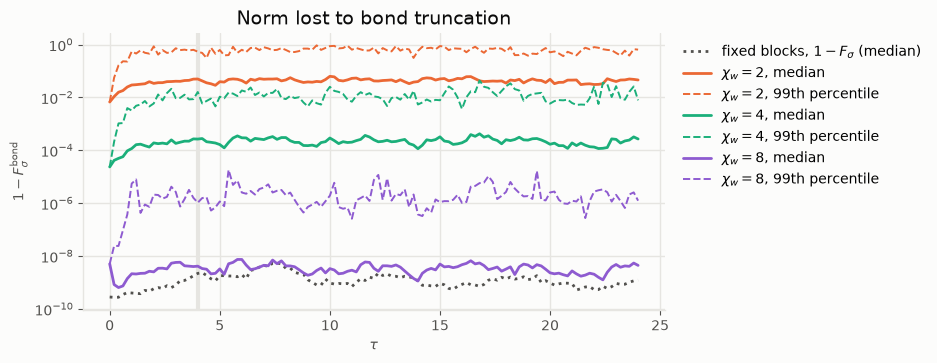

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_truncation_overlap_error.png


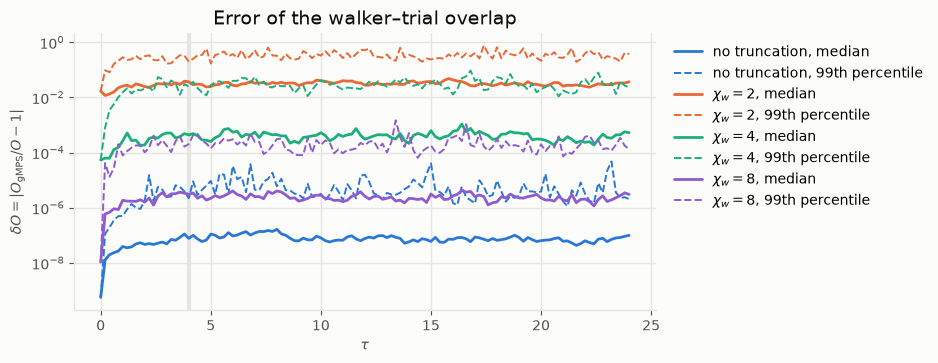

In [37]:
CHI_COLOR = {chi: PALETTE[i % len(PALETTE)] for i, chi in enumerate(TR)}
chi_label = lambda chi: "no truncation" if chi == 0 else rf"$\chi_w={chi}$"

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau, np.median(np.clip(1 - FF, 1e-17, None).reshape(len(tau), -1), axis=1), color=INK2, ls=":",
        label=r"fixed blocks, $1-F_\sigma$ (median)")
for chi in CHI_W:
    x = np.clip(1 - TR[chi]["f_bond"], 1e-17, None).reshape(len(tau), -1)
    ax.plot(tau, np.median(x, axis=1), color=CHI_COLOR[chi], label=f"{chi_label(chi)}, median")
    ax.plot(tau, np.percentile(x, 99, axis=1), color=CHI_COLOR[chi], ls="--", lw=1.4, label=f"{chi_label(chi)}, 99th percentile")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$1-F^{\rm bond}_\sigma$")
ax.set_title("Norm lost to bond truncation")
ax.legend(**LEGEND)
save(fig, "truncation_fidelity"); plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.6))
for chi in TR:
    x = np.clip(TR[chi]["dO"], 1e-17, None)
    ax.plot(tau, np.median(x, axis=1), color=CHI_COLOR[chi], label=f"{chi_label(chi)}, median")
    ax.plot(tau, np.percentile(x, 99, axis=1), color=CHI_COLOR[chi], ls="--", lw=1.4, label=f"{chi_label(chi)}, 99th percentile")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_yscale("log")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$\delta O=|O_{\rm gMPS}/O-1|$")
ax.set_title("Error of the walker–trial overlap")
ax.legend(**LEGEND)
save(fig, "truncation_overlap_error"); plt.show()

saved fw_block_data/L32_U4_nw200_eps1e-10_s1234_energy.png


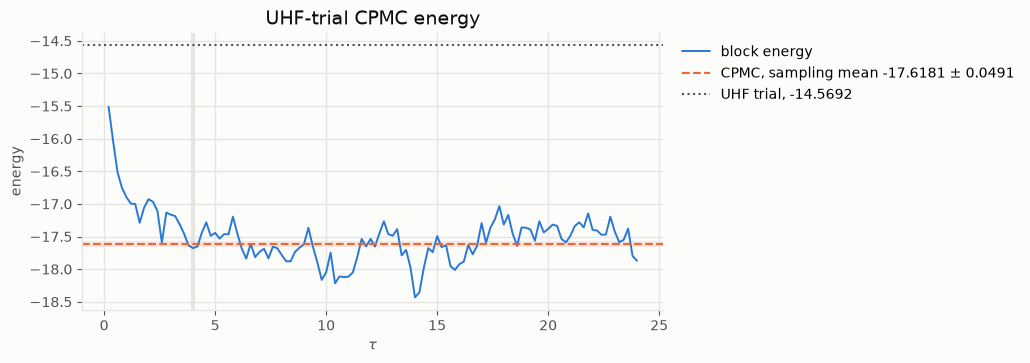

In [38]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(tau[1:], energies, color=PALETTE[0], lw=1.4, label="block energy")
ax.axhline(stats["mu"], color=PALETTE[1], ls="--", lw=1.5,
           label=f"CPMC, sampling mean {stats['mu']:.4f} ± {stats['se_star']:.4f}")
ax.axhspan(stats["mu"] - stats["se_star"], stats["mu"] + stats["se_star"], color=PALETTE[1], alpha=0.15, lw=0)
ax.axhline(E_UHF, color=INK2, ls=":", lw=1.5, label=f"UHF trial, {E_UHF:.4f}")
ax.axvline(tau[N_EQL], color=GRID, lw=3, zorder=0)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("energy")
ax.set_title("UHF-trial CPMC energy")
ax.legend(**LEGEND)
save(fig, "energy"); plt.show()

## Summary

At L=32, U=4, $\varepsilon=10^{-10}$, 200 walkers, 120 blocks (τ = 24), one seed:

- **Walkers do outgrow the plan, but only by one site.** The fixed plan uses $B=5$ in the bulk. Over the sampling phase, 66% of (walker, spin, site) block sizes equal the plan's and 27% are smaller (harmless). 6.5% are one site larger and 0.03% two sites larger. The median walker's largest block is 6, and the largest seen anywhere is 7.
- **The excess appears within τ≈1**, as soon as the walkers leave the reference, and then stays statistically flat. There is no drift with τ: the plots show a stationary distribution, not growth.
- **The norm it costs is tiny.** $1-F$ for the fixed plan has a median of $2\times10^{-9}$ against a floor of $1.5\times10^{-9}$ for the walkers' own plans, a 99th percentile of $5\times10^{-7}$ and a worst case of $3\times10^{-5}$ in 20,000 walker snapshots. It grows with the summed excess block size, so the loss really comes from blocks that are too small.
- **Bond truncation costs far more than the fixed blocks, at every $\chi_w$ tested.** For the walker–trial overlap error $\delta O$ over the sampling phase:

  | $\chi_w$ (d=4 bond $\chi_w^2$) | median | 99th percentile | worst |
  |---|---|---|---|
  | no truncation (fixed blocks only) | $8\times10^{-8}$ | $6\times10^{-6}$ | $3\times10^{-4}$ |
  | 8 (64) | $2\times10^{-6}$ | $2\times10^{-4}$ | $4\times10^{-3}$ |
  | 4 (16) | $4\times10^{-4}$ | $4\times10^{-2}$ | $0.26$ |
  | 2 (4) | $3\times10^{-2}$ | $0.38$ | $0.97$ |

  Even at $\chi_w=8$ the truncation error is about 30× the block error, at the median and at the 99th percentile. The plan's full bond here is 16, so $\chi_w\ge16$ is truncation-free, and only then do the fixed blocks set the error.
- **The fixed-block overlap error ($\sim10^{-7}$) is much larger than its norm loss ($\sim10^{-9}$) suggests.** $\delta O$ is relative to the walker's overlap with the trial, and a small $O$ amplifies it: the missing $\sqrt{1-F}\sim10^{-4.5}$ amplitude need not be orthogonal to the trial. The truncated $\delta O$ tracks $1-F^{\rm bond}$ more closely, because the truncation removes whole Schmidt components.
- **So the fixed-block approximation is not what limits the MPS-CPMC walkers.** Walker bond truncation is. An own-plan conversion would need a bond of $2^{6-1}=32$ instead of $16$ for most walkers, to remove an error that is already below the truncation error of any affordable $\chi_w$.

Caveats:

- This is one seed, at one $U$ and one $\varepsilon$.
- The trial is a UHF determinant, not the DMRG trial of the production runs. The walker ensemble, and so the tails of $1-F$ and $\delta O$, depend on the trial.
- The CPMC energy itself ($-17.62\pm0.05$, against the DMRG reference $\approx-18.00$ from earlier runs) carries the large constraint bias of a strongly symmetry-broken UHF trial. It is shown only as a sanity check of the run, not as a result.